# Geometric Detector — Smoothing Experiment Analysis

Varying `raster_blur_sigma` (Gaussian blur sigma in meters) at fixed resolution 0.12 m/px across 22 plots.

NOTE: This analysis is for results from experiment `tdf-benchmark-workflow-zlgxc` combined with `tdf-benchmark-workflow-8nll2`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

RESULTS_PATH = "/ofo-share/repos/amritha/tree-detection-eval-experiments/data/results/geometric_exps_smoothing_results_zlgxc_8nll2.csv"  # combined results file

df = pd.read_csv(RESULTS_PATH, dtype={"mission_id": str, "plot_id": str})

# Extract numeric sigma from config_id (e.g. "03_geometric_sigma_050" → 0.5)
def parse_sigma(config_id):
    suffix = config_id.split("sigma_")[-1]
    return 0.0 if suffix == "none" else int(suffix) / 100.0

df["sigma"] = df["config_id"].apply(parse_sigma)
df["dataset"] = df["mission_id"] + "\n" + df["plot_id"]
df["detection_ratio"] = df["n_core_drone"] / df["n_core_field"]

sigmas = sorted(df["sigma"].unique())
print(f"{len(df)} rows | {df['dataset'].nunique()} plots | sigma values: {sigmas}")

352 rows | 22 plots | sigma values: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]


## Figure 1: Mean F1 / Precision / Recall vs sigma

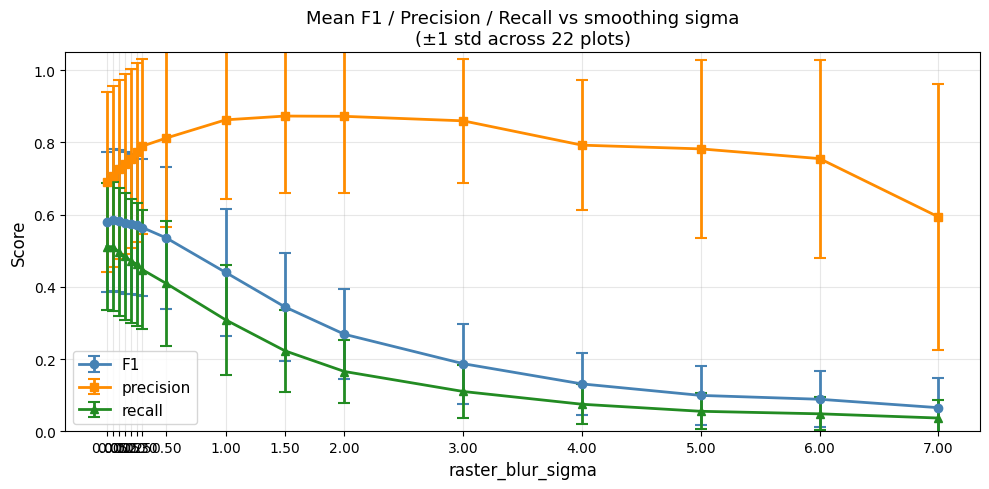

In [2]:
stats = df.groupby("sigma")[["F1", "precision", "recall"]].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(10, 5))

metric_styles = {
    "F1":        {"color": "steelblue",   "marker": "o"},
    "precision": {"color": "darkorange",  "marker": "s"},
    "recall":    {"color": "forestgreen", "marker": "^"},
}

for metric, style in metric_styles.items():
    means = stats[(metric, "mean")]
    stds  = stats[(metric, "std")]
    ax.errorbar(
        sigmas, means, yerr=stds,
        label=metric, color=style["color"], marker=style["marker"],
        linewidth=2, markersize=6, capsize=4, capthick=1.5,
    )

ax.set_xlabel("raster_blur_sigma", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Mean F1 / Precision / Recall vs smoothing sigma\n(±1 std across 22 plots)", fontsize=13)
ax.set_xticks(sigmas)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Equally spaced (not to scale) data points in x-axis:

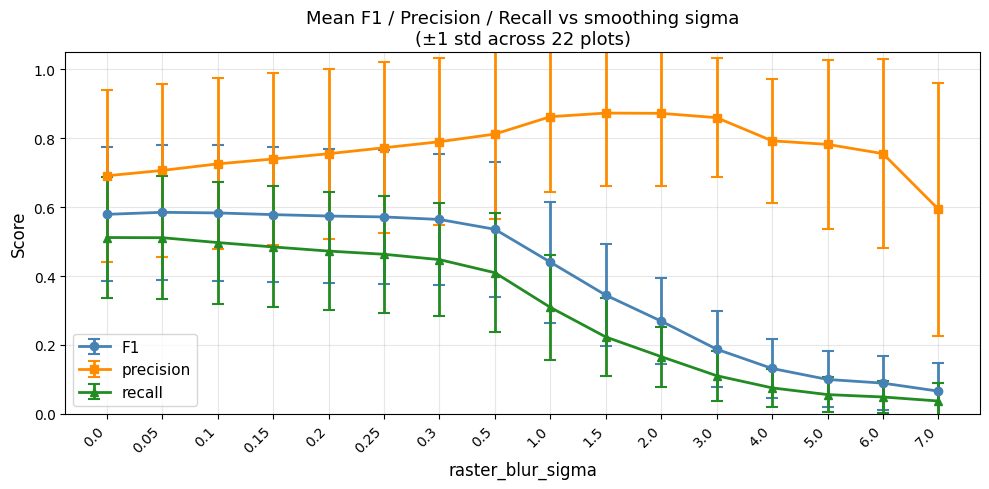

In [3]:
stats = df.groupby("sigma")[["F1", "precision", "recall"]].agg(["mean", "std"])
x = list(range(len(sigmas)))

fig, ax = plt.subplots(figsize=(10, 5))

metric_styles = {
    "F1":        {"color": "steelblue",   "marker": "o"},
    "precision": {"color": "darkorange",  "marker": "s"},
    "recall":    {"color": "forestgreen", "marker": "^"},
}

for metric, style in metric_styles.items():
    means = stats[(metric, "mean")]
    stds  = stats[(metric, "std")]
    ax.errorbar(
        x, means, yerr=stds,
        label=metric, color=style["color"], marker=style["marker"],
        linewidth=2, markersize=6, capsize=4, capthick=1.5,
    )

ax.set_xlabel("raster_blur_sigma", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Mean F1 / Precision / Recall vs smoothing sigma\n(±1 std across 22 plots)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in sigmas], rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Figure 2: Per-plot F1 vs sigma (spaghetti)

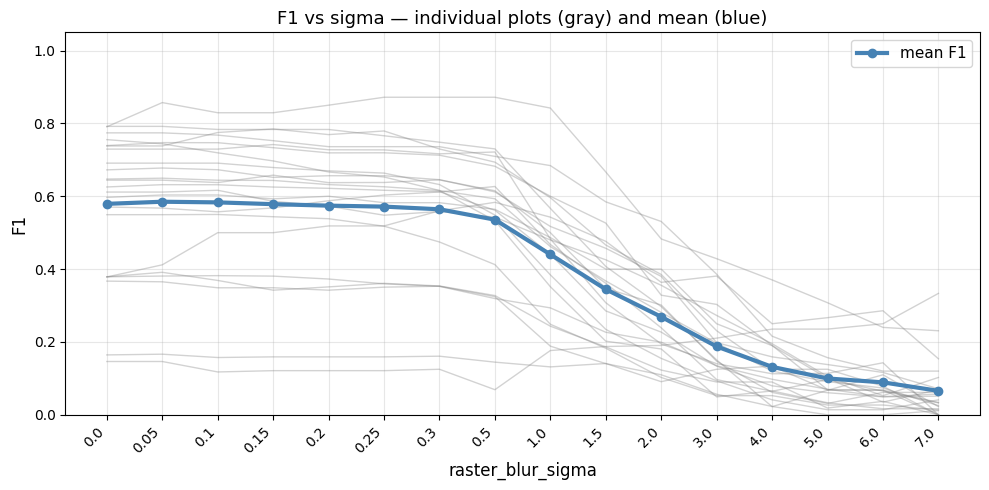

In [4]:
sigma_to_x = {s: i for i, s in enumerate(sigmas)}

fig, ax = plt.subplots(figsize=(10, 5))

for dataset, grp in df.groupby("dataset"):
    grp = grp.sort_values("sigma")
    xs = [sigma_to_x[s] for s in grp["sigma"]]
    ax.plot(xs, grp["F1"], color="gray", alpha=0.35, linewidth=1)

mean_f1 = df.groupby("sigma")["F1"].mean()
ax.plot(list(range(len(sigmas))), mean_f1, color="steelblue", linewidth=3, marker="o", markersize=6, label="mean F1")

ax.set_xlabel("raster_blur_sigma", fontsize=12)
ax.set_ylabel("F1", fontsize=12)
ax.set_title("F1 vs sigma — individual plots (gray) and mean (blue)", fontsize=13)
ax.set_xticks(list(range(len(sigmas))))
ax.set_xticklabels([str(s) for s in sigmas], rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Figure 3: Precision–Recall tradeoff by sigma

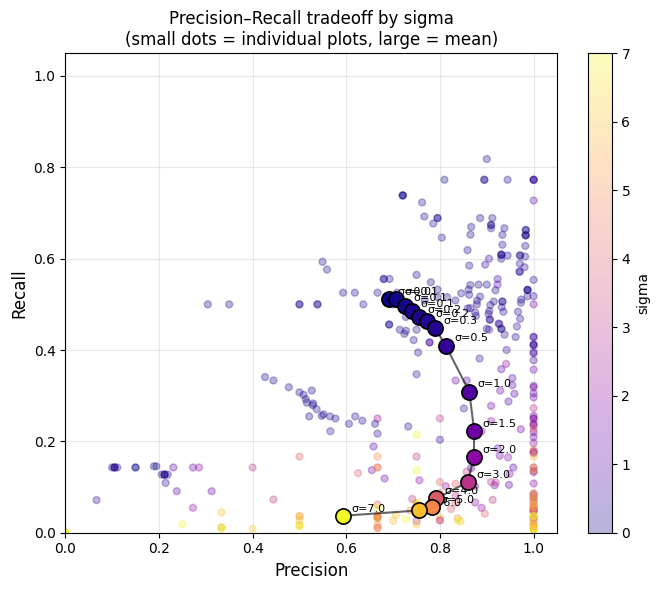

In [5]:
mean_pr = df.groupby("sigma")[["precision", "recall"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 6))

# Individual plot scatter (small, light)
sc = ax.scatter(
    df["precision"], df["recall"],
    c=df["sigma"], cmap="plasma", alpha=0.3, s=25, zorder=2,
)

# Mean per sigma (large markers connected by a line)
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=max(sigmas))
ax.plot(mean_pr["precision"], mean_pr["recall"], color="black", linewidth=1.5, zorder=3, alpha=0.6)
for _, row in mean_pr.iterrows():
    ax.scatter(row["precision"], row["recall"],
               color=cmap(norm(row["sigma"])), s=120, edgecolors="black",
               linewidths=1.2, zorder=4)
    ax.annotate(f"σ={row['sigma']:.1f}", (row["precision"], row["recall"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("sigma", fontsize=10)

ax.set_xlabel("Precision", fontsize=12)
ax.set_ylabel("Recall", fontsize=12)
ax.set_title("Precision–Recall tradeoff by sigma\n(small dots = individual plots, large = mean)", fontsize=12)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 4: F1 heatmap — plot × sigma

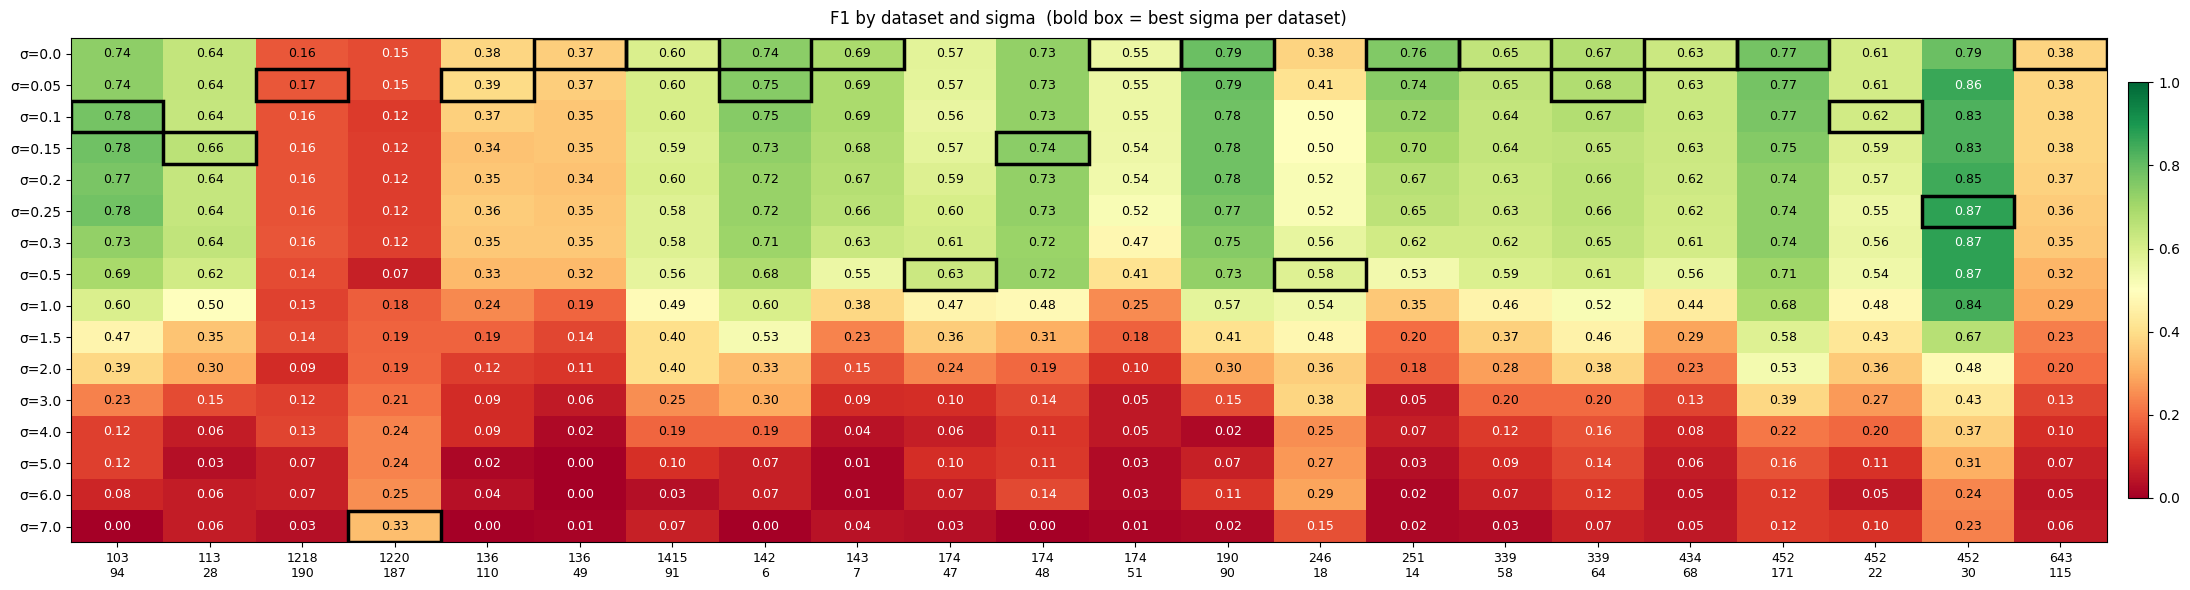

In [6]:
pivot = df.pivot_table(index="sigma", columns="dataset", values="F1")

fig, ax = plt.subplots(figsize=(22, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

for row_i in range(pivot.shape[0]):
    for col_j in range(pivot.shape[1]):
        val = pivot.values[row_i, col_j]
        if np.isnan(val):
            continue
        rgb = mcolors.to_rgb(plt.cm.RdYlGn(val))
        luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
        ax.text(col_j, row_i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color="black" if luminance > 0.5 else "white")

# Box around the best sigma per dataset. Ties are judged on the *displayed*
# (2-decimal-rounded) value, since that's what looks tied to the eye; among
# those tied rows, prefer the lowest sigma.
sigma_values = pivot.index.to_numpy()
rounded = np.round(pivot.values, 2)
best_row_per_col = []
for col_j in range(pivot.shape[1]):
    col = rounded[:, col_j]
    max_val = np.nanmax(col)
    tied_rows = np.flatnonzero(col == max_val)
    best_row_per_col.append(tied_rows[np.argmin(sigma_values[tied_rows])])

for col_j, row_i in enumerate(best_row_per_col):
    ax.add_patch(plt.Rectangle(
        (col_j - 0.5, row_i - 0.5), 1, 1,
        fill=False, edgecolor="black", linewidth=2.5
    ))

ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([f"σ={s}" for s in pivot.index], fontsize=10)
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_title("F1 by dataset and sigma  (bold box = best sigma per dataset)", fontsize=12, pad=10)
plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)
plt.tight_layout()
plt.show()

## Figure 5: F1 box plot by sigma

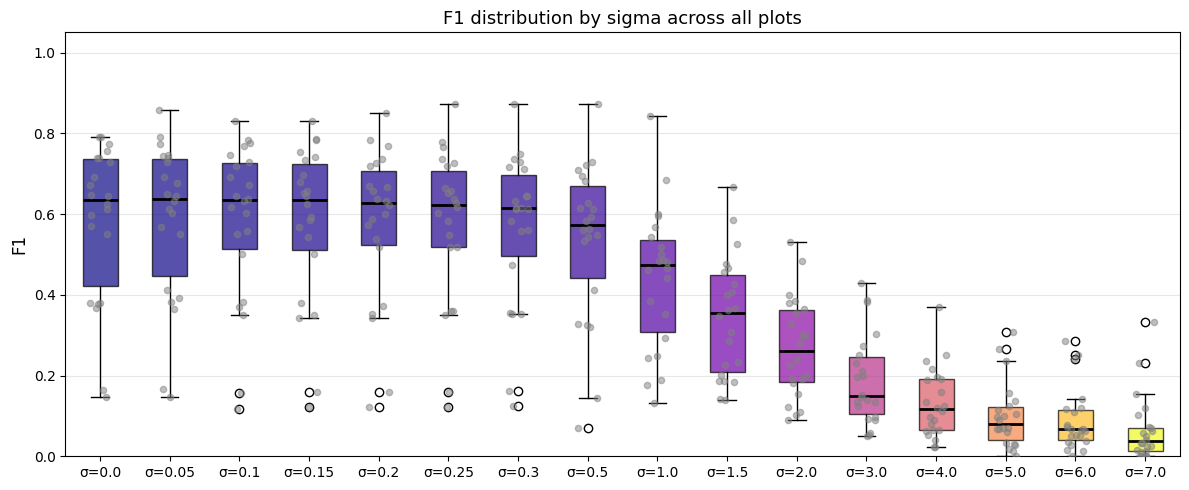

In [7]:
groups = [df[df["sigma"] == s]["F1"].values for s in sigmas]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(groups, patch_artist=True, medianprops={"color": "black", "linewidth": 2})

cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=0, vmax=max(sigmas))
for patch, s in zip(bp["boxes"], sigmas):
    patch.set_facecolor(cmap(norm(s)))
    patch.set_alpha(0.7)

# Overlay individual points
for i, (s, vals) in enumerate(zip(sigmas, groups), start=1):
    ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.15, 0.15, len(vals)),
               vals, color="gray", alpha=0.5, s=20, zorder=3)

ax.set_xticks(range(1, len(sigmas) + 1))
ax.set_xticklabels([f"σ={s}" for s in sigmas], fontsize=10)
ax.set_ylabel("F1", fontsize=12)
ax.set_title("F1 distribution by sigma across all plots", fontsize=13)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Summary table

In [8]:
summary = df.groupby("sigma").agg(
    F1_mean=("F1", "mean"),
    F1_std=("F1", "std"),
    precision_mean=("precision", "mean"),
    recall_mean=("recall", "mean"),
    detection_ratio_mean=("detection_ratio", "mean"),
).round(3)

# Highlight the best F1 row
summary.style.highlight_max(subset=["F1_mean"], color="green")

,F1_mean,F1_std,precision_mean,recall_mean,detection_ratio_mean
sigma,,,,,
0.000000,0.579000,0.194000,0.691000,0.512000,0.809000
0.050000,0.585000,0.196000,0.707000,0.511000,0.782000
0.100000,0.583000,0.197000,0.726000,0.497000,0.727000
0.150000,0.578000,0.197000,0.740000,0.484000,0.695000
0.200000,0.574000,0.194000,0.755000,0.472000,0.664000
0.250000,0.572000,0.194000,0.772000,0.463000,0.642000
0.300000,0.564000,0.190000,0.790000,0.448000,0.602000
0.500000,0.536000,0.196000,0.812000,0.410000,0.528000
1.000000,0.440000,0.176000,0.863000,0.309000,0.391000
